In [18]:
import matplotlib.pyplot as plt
import json
import numpy as np
import seaborn as sns
import pandas as pd
from ast import literal_eval
from sklearn.manifold import TSNE

In [28]:
all_df = pd.read_csv('/data/wang/junh/results/Fuse_moe/all_los/multiclass/dynamic_weighted/TS_CXR_Text_ECG_test_results.csv')
print(all_df.head())

                ids  Predicted  Ground_Truth  \
0  2769871338191620          1             2   
1  2648608136349817          0             0   
2  2665266630324860          1             2   
3  2731529236478422          1             1   
4  2318286737909743          0             1   

                                               Probs  \
0  [0.2615013122558594, 0.5563079714775085, 0.141...   
1  [0.6061091423034668, 0.35010460019111633, 0.02...   
2  [0.45380106568336487, 0.4677492678165436, 0.06...   
3  [0.36984366178512573, 0.5386450886726379, 0.07...   
4  [0.5198186635971069, 0.4164641499519348, 0.049...   

                                                Proj  
0  [-0.92578125, -0.34814453125, -2.03515625, 2.6...  
1  [-1.0419921875, -0.5107421875, -0.128784179687...  
2  [-1.8427734375, -0.41357421875, 0.054107666015...  
3  [-1.904296875, -1.220703125, 0.61767578125, 2....  
4  [-1.12109375, -0.69287109375, -0.458251953125,...  


In [29]:
all_df['Proj'] = all_df['Proj'].apply(lambda x: np.array(literal_eval(x)))
all_proj = np.array(all_df['Proj'].values)

ts_proj = []
cxr_proj = []
text_proj = []
ecg_proj = []
proj_4 = []
for proj in all_proj:
    ts_proj.append(proj[0:128])
    cxr_proj.append(proj[128:256])
    text_proj.append(proj[256:384])
    ecg_proj.append(proj[384:512])
    proj_4.append(proj[0:512])

all_df['TS_Proj'] = ts_proj
all_df['CXR_Proj'] = cxr_proj
all_df['Text_Proj'] = text_proj
all_df['ECG_Proj'] = ecg_proj

all_df['flag'] = 1
for i in range(len(all_df)):
    if all_df['Predicted'][i] == all_df['Ground_Truth'][i]:
        all_df['flag'][i] = 0

<ipython-input-29-139114450643>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df['flag'][i] = 0


In [9]:
import matplotlib.pyplot as plt
import umap.umap_ as umap
import numpy as np

def plot_umap(modality, modality_proj, ground_truth, n_neighbors=15, min_dist=0.1, random_state=42, title_prefix="UMAP Visualization"):
    """
    Generate and plot a UMAP visualization.

    Parameters:
        modality_proj (np.ndarray): Input feature projections for UMAP.
        ground_truth (array-like): Labels corresponding to the projections.
        n_neighbors (int): Number of neighbors for UMAP (default: 15).
        min_dist (float): Minimum distance between points in the UMAP projection (default: 0.1).
        random_state (int): Random state for consistent UMAP results (default: 42).
        title_prefix (str): Prefix for the plot title (default: "UMAP Visualization").
    """
    # Perform UMAP dimensionality reduction
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=random_state)
    embedding = reducer.fit_transform(modality_proj)

    # Define unique classes and colors
    unique_labels = np.unique(ground_truth)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

    # Create the scatter plot
    plt.figure(figsize=(10, 8))
    for i, label in enumerate(unique_labels):
        plt.scatter(
            embedding[np.array(ground_truth) == label, 0],
            embedding[np.array(ground_truth) == label, 1],
            color=colors[i],
            label=f'Class {label}',
            alpha=0.8
        )

    # Add legend and labels
    plt.legend(title="Ground Truth", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.title(f"{title_prefix} for {modality}-dimensional features")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.grid(True)

    # Adjust layout and show the plot
    try:
        plt.tight_layout()
    except ValueError:
        plt.subplots_adjust(right=0.8)

    plt.show()

# Example usage (replace with your data)
# plot_umap(modality_proj=ts_proj, ground_truth=all_df['Ground_Truth'])


/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


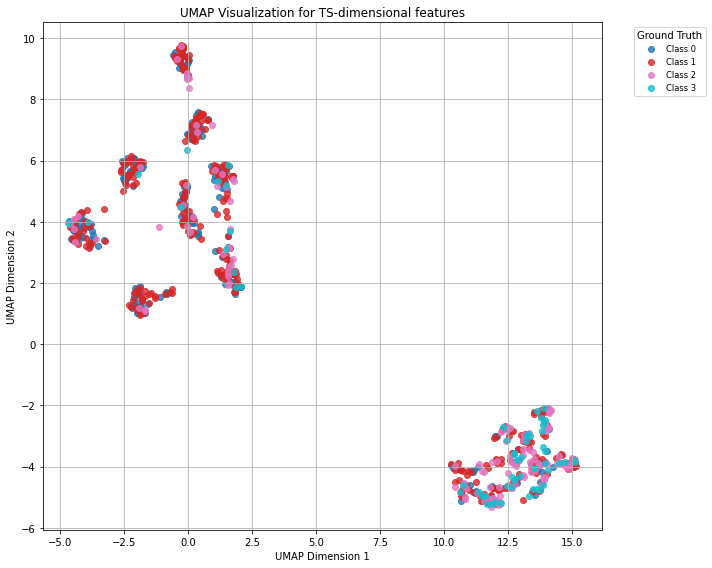

In [23]:
plot_umap('TS', modality_proj=ts_proj, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


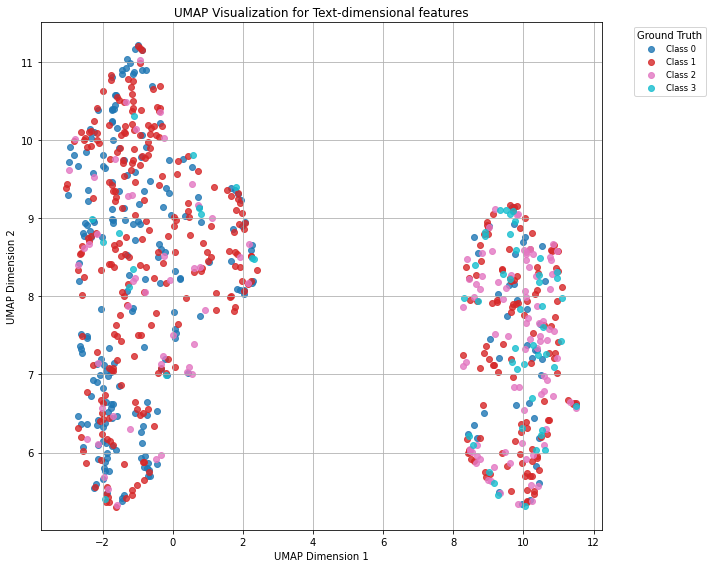

In [30]:
plot_umap('Text', modality_proj=text_proj, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


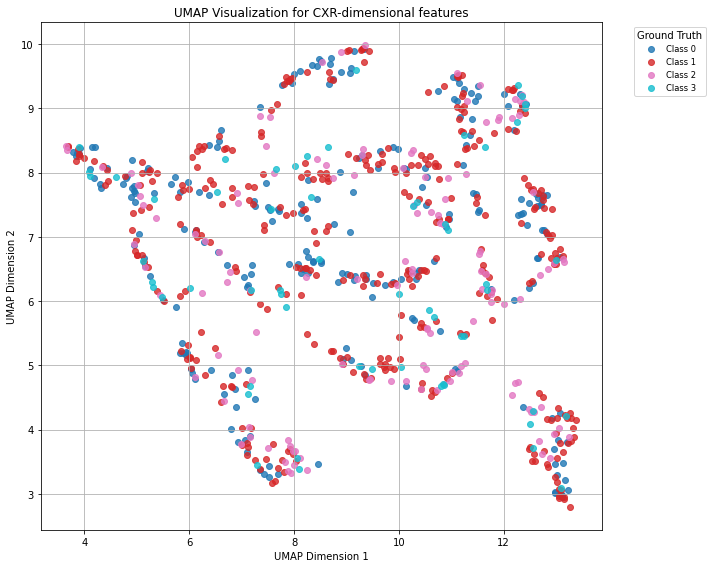

In [22]:
# Dynamic Weighted
plot_umap('CXR', modality_proj=cxr_proj, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


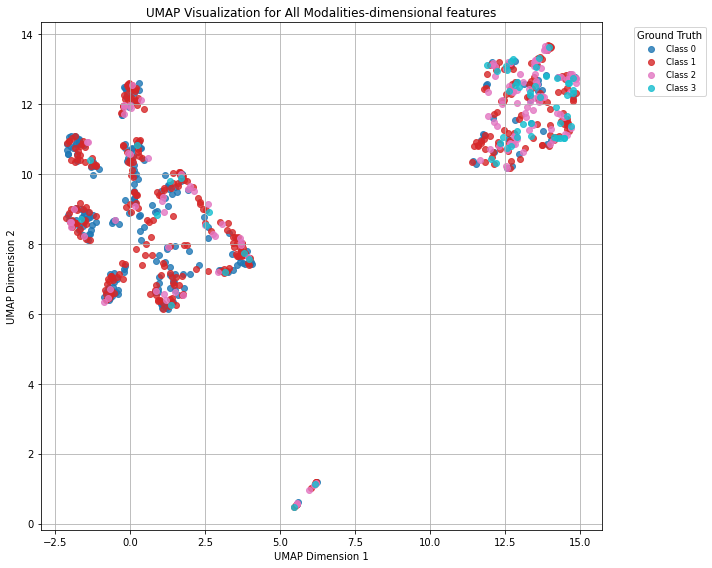

In [ ]:
# Dynamic Weighted
plot_umap('All Modalities', modality_proj=proj_4, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


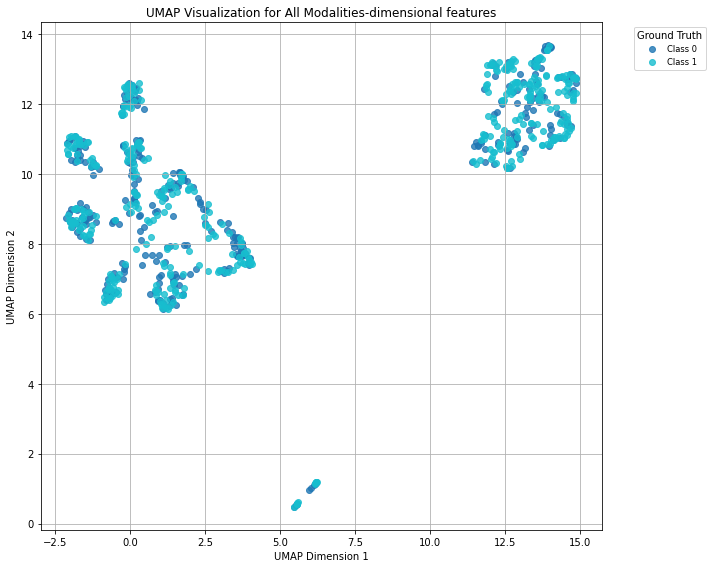

In [21]:
plot_umap('All Modalities', modality_proj=proj_4, ground_truth=all_df['flag'])

In [24]:
all_df = pd.read_csv('/data/wang/junh/results/Fuse_moe/all_los/multiclass/weighted/TS_CXR_Text_ECG_test_results.csv')
print(all_df.head())

                ids  Predicted  Ground_Truth  \
0  2769871338191620          0             2   
1  2648608136349817          0             0   
2  2665266630324860          0             2   
3  2731529236478422          1             1   
4  2318286737909743          0             1   

                                               Probs  \
0  [0.4354931712150574, 0.35962897539138794, 0.16...   
1  [0.5666986703872681, 0.41785740852355957, 0.01...   
2  [0.48480847477912903, 0.47869259119033813, 0.0...   
3  [0.40771299600601196, 0.5179202556610107, 0.05...   
4  [0.5062456727027893, 0.4709520936012268, 0.020...   

                                                Proj  
0  [-0.91552734375, -0.305908203125, -1.008789062...  
1  [-1.080078125, -0.7470703125, 1.2421875, 1.866...  
2  [-1.1611328125, -0.341064453125, 1.3828125, 1....  
3  [-1.0302734375, -0.5986328125, 1.1875, 1.68847...  
4  [-1.0693359375, -0.2222900390625, 1.314453125,...  


In [25]:
all_df['Proj'] = all_df['Proj'].apply(lambda x: np.array(literal_eval(x)))
all_proj = np.array(all_df['Proj'].values)

ts_proj = []
cxr_proj = []
text_proj = []
ecg_proj = []
proj_4 = []
for proj in all_proj:
    ts_proj.append(proj[0:128])
    cxr_proj.append(proj[128:256])
    text_proj.append(proj[256:384])
    ecg_proj.append(proj[384:512])
    proj_4.append(proj[0:512])

all_df['TS_Proj'] = ts_proj
all_df['CXR_Proj'] = cxr_proj
all_df['Text_Proj'] = text_proj
all_df['ECG_Proj'] = ecg_proj

all_df['flag'] = 1
for i in range(len(all_df)):
    if all_df['Predicted'][i] == all_df['Ground_Truth'][i]:
        all_df['flag'][i] = 0

<ipython-input-25-139114450643>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df['flag'][i] = 0


/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


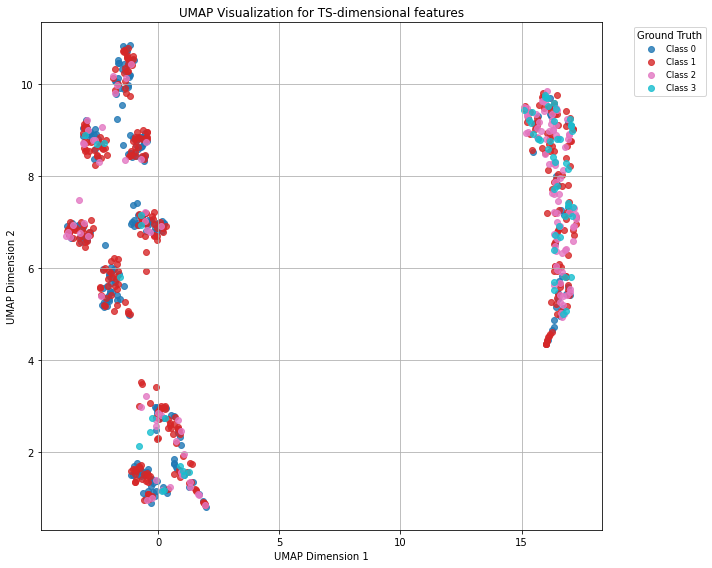

In [26]:
plot_umap('TS', modality_proj=ts_proj, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


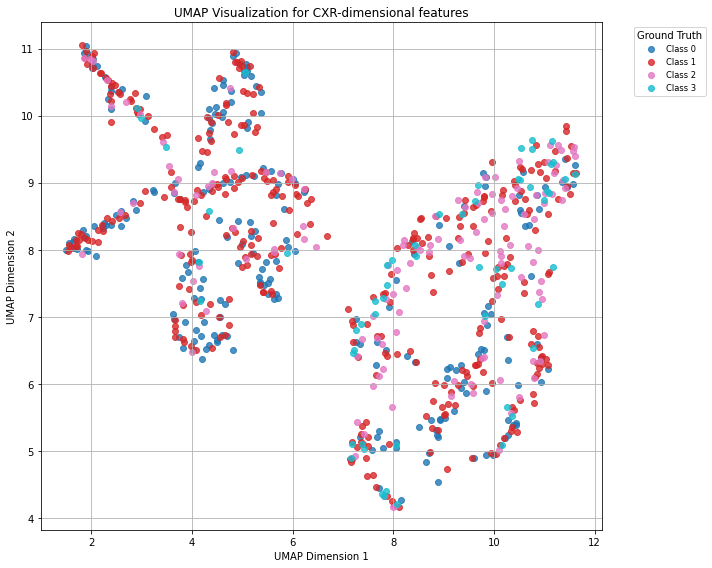

In [27]:
plot_umap('CXR', modality_proj=cxr_proj, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


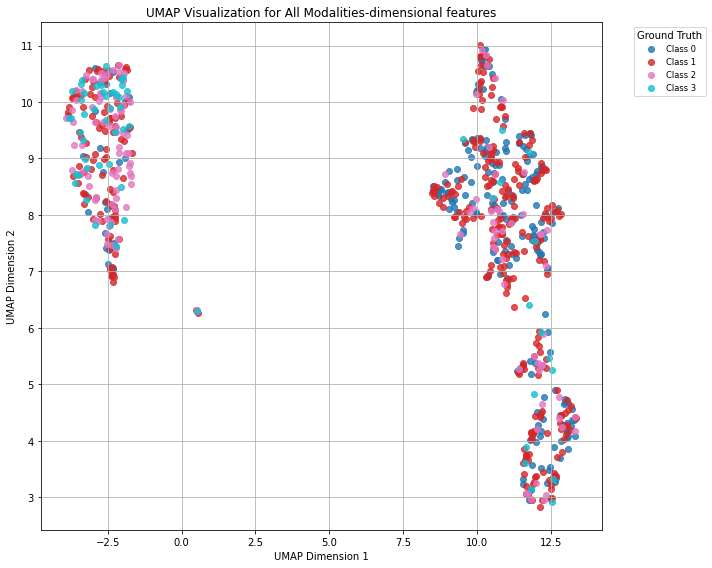

In [16]:
# Fixed Weighted
plot_umap('All Modalities', modality_proj=proj_4, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


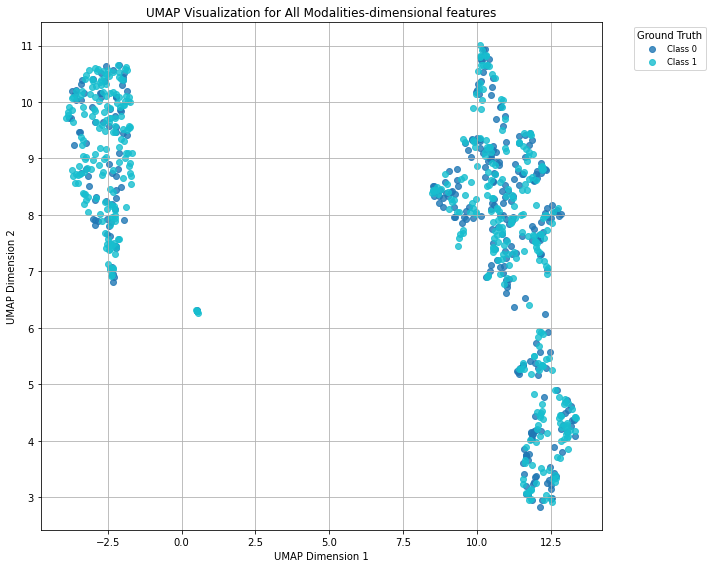

In [17]:
# Positive flag = truth prediction
plot_umap('All Modalities', modality_proj=proj_4, ground_truth=all_df['flag'])

In [31]:
# Bilevel
all_df = pd.read_csv('/data/wang/junh/results/Fuse_moe/all_los/multiclass/dynamic_bilevel/TS_CXR_Text_ECG_test_results.csv')
print(all_df.head())

                ids  Predicted  Ground_Truth  \
0  2769871338191620          1             2   
1  2648608136349817          0             0   
2  2665266630324860          0             2   
3  2731529236478422          1             1   
4  2318286737909743          0             1   

                                               Probs  \
0  [0.25807344913482666, 0.5402401685714722, 0.16...   
1  [0.5488780736923218, 0.42166221141815186, 0.02...   
2  [0.5256252884864807, 0.4198842942714691, 0.047...   
3  [0.34741541743278503, 0.568333625793457, 0.069...   
4  [0.5003620982170105, 0.44459691643714905, 0.04...   

                                                Proj  
0  [-0.62841796875, -0.5537109375, -1.642578125, ...  
1  [-0.94580078125, -0.07220458984375, 0.09997558...  
2  [-1.6328125, -0.57958984375, -0.2462158203125,...  
3  [-1.154296875, -0.4853515625, -1.0546875, 3.25...  
4  [-0.97900390625, -0.417724609375, -0.861328125...  


In [32]:
all_df['Proj'] = all_df['Proj'].apply(lambda x: np.array(literal_eval(x)))
all_proj = np.array(all_df['Proj'].values)

ts_proj = []
cxr_proj = []
text_proj = []
ecg_proj = []
proj_4 = []
for proj in all_proj:
    ts_proj.append(proj[0:128])
    cxr_proj.append(proj[128:256])
    text_proj.append(proj[256:384])
    ecg_proj.append(proj[384:512])
    proj_4.append(proj[0:512])

all_df['TS_Proj'] = ts_proj
all_df['CXR_Proj'] = cxr_proj
all_df['Text_Proj'] = text_proj
all_df['ECG_Proj'] = ecg_proj

all_df['flag'] = 1
for i in range(len(all_df)):
    if all_df['Predicted'][i] == all_df['Ground_Truth'][i]:
        all_df['flag'][i] = 0

<ipython-input-32-139114450643>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df['flag'][i] = 0


/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


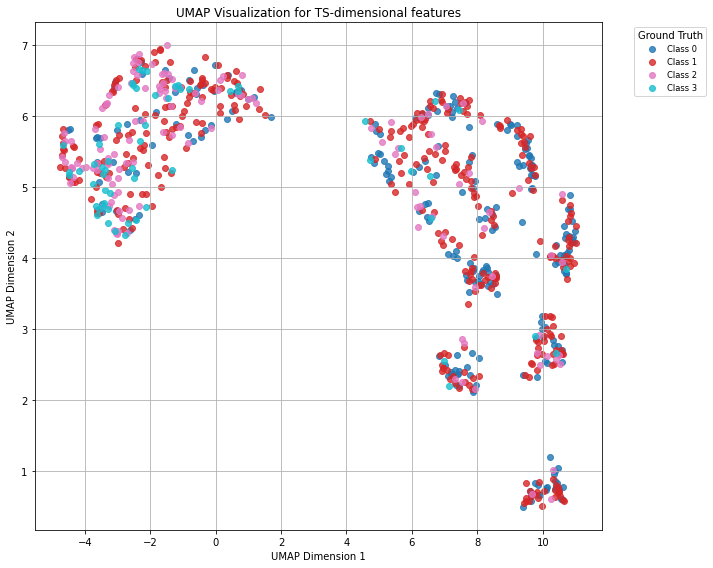

In [33]:
plot_umap('TS', modality_proj=ts_proj, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


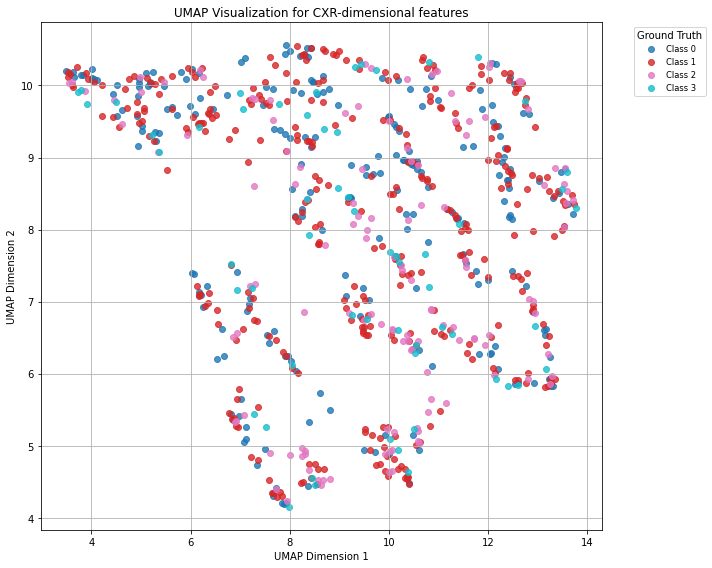

In [34]:
plot_umap('CXR', modality_proj=cxr_proj, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


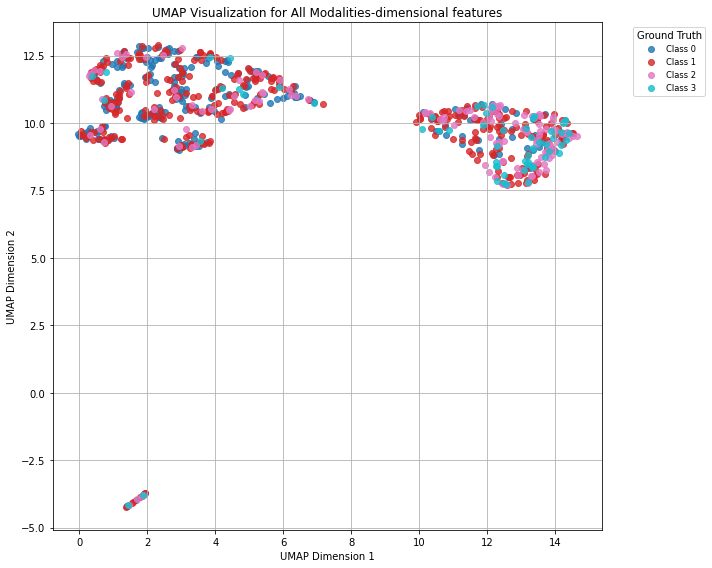

In [35]:
plot_umap('All Modalities', modality_proj=proj_4, ground_truth=all_df['Ground_Truth'])

In [37]:
# JSD
all_df = pd.read_csv('/data/wang/junh/results/Fuse_moe/all_los/multiclass/dynamic_jsd/TS_CXR_Text_ECG_test_results.csv')
print(all_df.head())
all_df['Proj'] = all_df['Proj'].apply(lambda x: np.array(literal_eval(x)))
all_proj = np.array(all_df['Proj'].values)

ts_proj = []
cxr_proj = []
text_proj = []
ecg_proj = []
proj_4 = []
for proj in all_proj:
    ts_proj.append(proj[0:128])
    cxr_proj.append(proj[128:256])
    text_proj.append(proj[256:384])
    ecg_proj.append(proj[384:512])
    proj_4.append(proj[0:512])

all_df['TS_Proj'] = ts_proj
all_df['CXR_Proj'] = cxr_proj
all_df['Text_Proj'] = text_proj
all_df['ECG_Proj'] = ecg_proj

all_df['flag'] = 1
for i in range(len(all_df)):
    if all_df['Predicted'][i] == all_df['Ground_Truth'][i]:
        all_df['flag'][i] = 0

                ids  Predicted  Ground_Truth  \
0  2769871338191620          2             2   
1  2648608136349817          0             0   
2  2665266630324860          1             2   
3  2731529236478422          0             1   
4  2318286737909743          0             1   

                                               Probs  \
0  [0.03555520251393318, 0.28406739234924316, 0.4...   
1  [0.6589397192001343, 0.2975880801677704, 0.035...   
2  [0.30282604694366455, 0.468568354845047, 0.194...   
3  [0.4246465861797333, 0.4119836986064911, 0.134...   
4  [0.5389343500137329, 0.36608847975730896, 0.08...   

                                                Proj  
0  [1.2373046875, -0.5078125, -1.4619140625, -0.3...  
1  [-1.2783203125, -0.57763671875, 0.087768554687...  
2  [-2.25390625, -0.259765625, -0.60791015625, 1....  
3  [-1.6455078125, -0.400390625, -0.0500183105468...  
4  [-0.93994140625, -0.47802734375, -0.4282226562...  


<ipython-input-37-47431b4819c1>:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df['flag'][i] = 0


/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


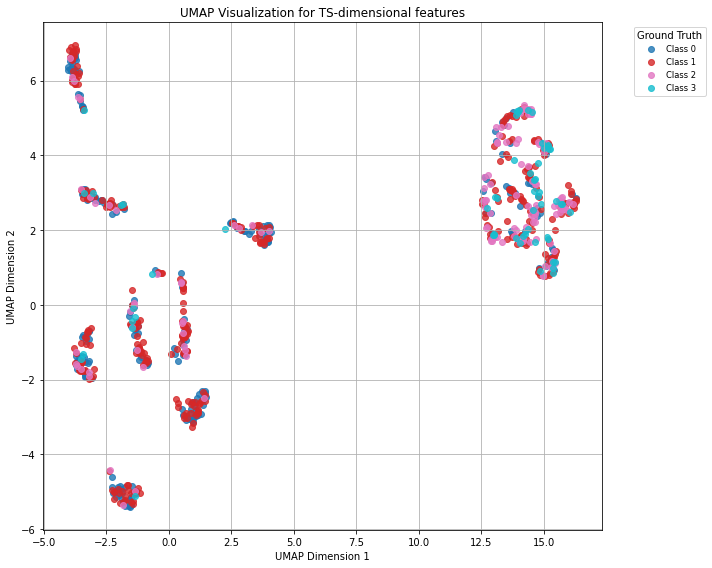

In [38]:
plot_umap('TS', modality_proj=ts_proj, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


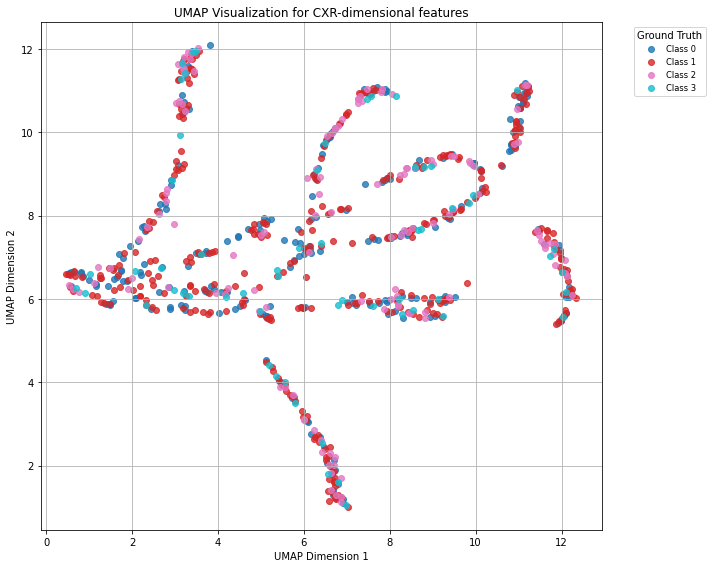

In [39]:
plot_umap('CXR', modality_proj=cxr_proj, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


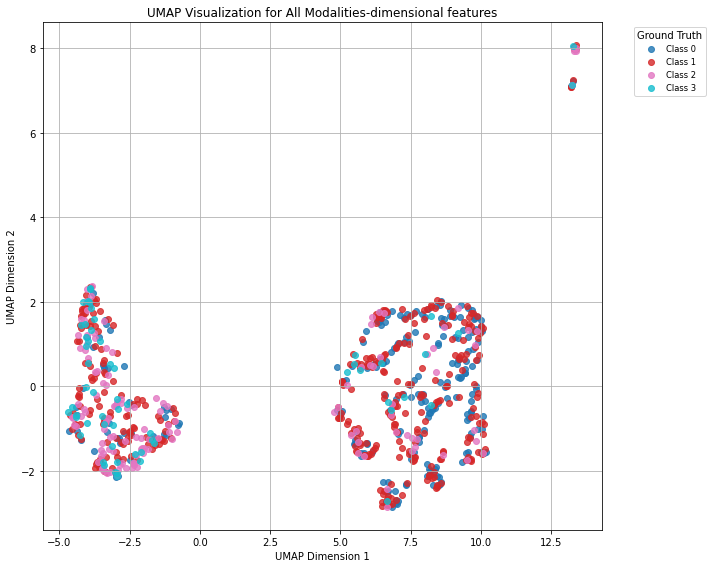

In [40]:
plot_umap('All Modalities', modality_proj=proj_4, ground_truth=all_df['Ground_Truth'])